In [1]:
import sys
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
from glob import glob
from sklearn.utils import resample

In [3]:
import pymbar
sys.path.append("/Users/van/Scripts/pybin")
from mbar_pmf import mbar_pmf #If does not work, check mbar_pmf2 from /home/van/scripts

In [4]:
!pwd

/Users/van/spycas9/pmf/wt/mbar


In [9]:
ene_b3lyp = np.load('../../../2-qmmm/wt/tp_energy/qmmm_b3lyp_6-31gd_energy.npy')*627.5 
ene_b3lyp_d = np.load('../../../2-qmmm/wt/tp_energy/qmmm_b3lyp_6-31+gd_energy.npy')*627.5

ene_wb97xd = np.load('../../../2-qmmm/wt/tp_energy/qmmm_wb97xd_6-31gd_energy.npy')*627.5
ene_wb97xd_d = np.load('../../../2-qmmm/wt/tp_energy/qmmm_wb97xd_6-31+gd_energy.npy')*627.5 

ene_blyp = np.load('../../../2-qmmm/wt/tp_energy/qmmm_blyp_6-31gd_energy.npy')*627.5
ene_blyp_d = np.load('../../../2-qmmm/wt/tp_energy/qmmm_blyp_6-31+gd_energy.npy')*627.5

In [ ]:
n_windows = 42
val_kn = []
for i in range(n_windows):
    fnames = sorted(glob('../%02d/step6.0?_equilibration.cv' % i))
    arrays = [np.loadtxt(f, usecols=0)[::] for f in fnames[:]]
    val_kn.append(np.concatenate(arrays))
    
val0_k = np.linspace(-1.90, 2.20, n_windows)
K_k = np.ones(n_windows) * 300.0
val_min = -1.90
val_max = 2.20
nbins = n_windows -1 

In [10]:
# n_windows = 42
# val_kn = np.load('cvs.npy')
# val0_k = np.linspace(-1.90, 2.20, n_windows)
# K_k = np.ones(n_windows) * 300.0
# val_min = -1.90
# val_max = 2.20
# nbins = n_windows -1 

In [11]:
for i in range(n_windows):
    print("Window %02d:" % i, pymbar.timeseries.subsampleCorrelatedData(val_kn[i], conservative=True))

Window 00: range(0, 250)
Window 01: range(0, 250)
Window 02: range(0, 250)
Window 03: range(0, 250)
Window 04: range(0, 250)
Window 05: range(0, 250)
Window 06: range(0, 250)
Window 07: range(0, 250, 2)
Window 08: range(0, 250, 2)
Window 09: range(0, 250, 2)
Window 10: range(0, 250, 2)
Window 11: range(0, 250)
Window 12: range(0, 250, 2)
Window 13: range(0, 250)
Window 14: range(0, 250, 2)
Window 15: range(0, 250)
Window 16: range(0, 250)
Window 17: range(0, 250)
Window 18: range(0, 250, 2)
Window 19: range(0, 250, 3)
Window 20: range(0, 250)
Window 21: range(0, 250)
Window 22: range(0, 250)
Window 23: range(0, 250, 2)
Window 24: range(0, 250, 2)
Window 25: range(0, 250)
Window 26: range(0, 250)
Window 27: range(0, 250, 2)
Window 28: range(0, 250, 2)
Window 29: range(0, 250)
Window 30: range(0, 250, 2)
Window 31: range(0, 250, 2)
Window 32: range(0, 250)
Window 33: range(0, 250)
Window 34: range(0, 250, 2)
Window 35: range(0, 250, 3)
Window 36: range(0, 250, 2)
Window 37: range(0, 250)

In [12]:
mbar = mbar_pmf(val_kn, val0_k, K_k, 300.0, u_kn=ene_b3lyp) # References the lower level theory
# mbar = mbar_pmf(val_kn, val0_k, K_k, 300.0)

K (total states) = 42, total samples = 10500
N_k = 
[250 250 250 250 250 250 250 250 250 250 250 250 250 250 250 250 250 250
 250 250 250 250 250 250 250 250 250 250 250 250 250 250 250 250 250 250
 250 250 250 250 250 250]
There are 42 states with samples.
Initial dimensionless free energies with method BAR
f_k = 
[ 0.          0.29937768  0.6205884   0.92090295  1.42347742  2.04209284
  2.85426332  4.02031165  5.53202109  6.95675611  8.67431506 10.81421238
 13.52609919 16.38735688 19.38697485 22.73848214 26.20289374 29.70875562
 32.90603244 34.65074364 34.89502593 34.97272648 34.81712747 34.17850124
 33.4406631  31.78825906 29.52823905 27.39601701 25.23436212 23.06206917
 21.27296148 19.33960206 17.55831332 15.82791495 14.2962037  13.00552815
 11.88160994 11.21222737 10.507411   10.09068587  9.32787732  8.67881429]
Determining dimensionless free energies by Newton-Raphson / self-consistent iteration.
self consistent iteration gradient norm is     5.3499, Newton-Raphson gradient norm 

Barrier Height (kcal/mol): 20.81
Mean Uncertainty (kcal/mol): 0.35
Max Uncertainty (kcal/mol): 0.54


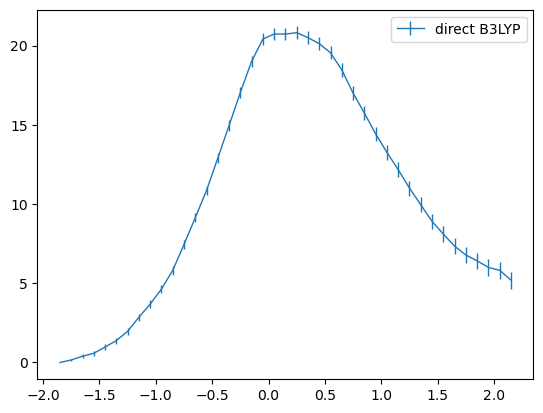

In [13]:
bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins, u_kn=ene_b3lyp)
bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins, uncertainties='from-specified', pmf_reference=f_i[:20].argmin())

plt.errorbar(bin_centers, f_i - f_i[0], yerr=df_i, linewidth=1, label="direct B3LYP")
plt.legend()
# np.savetxt("freefile_mbar_b3lyp", np.column_stack((bin_centers, f_i, df_i)), fmt="%.2f %f %f")
print("Barrier Height (kcal/mol): %.2f" % (f_i.max() - f_i.min()))
print("Mean Uncertainty (kcal/mol): %.2f" % df_i.mean())
print("Max Uncertainty (kcal/mol): %.2f" % df_i.max())

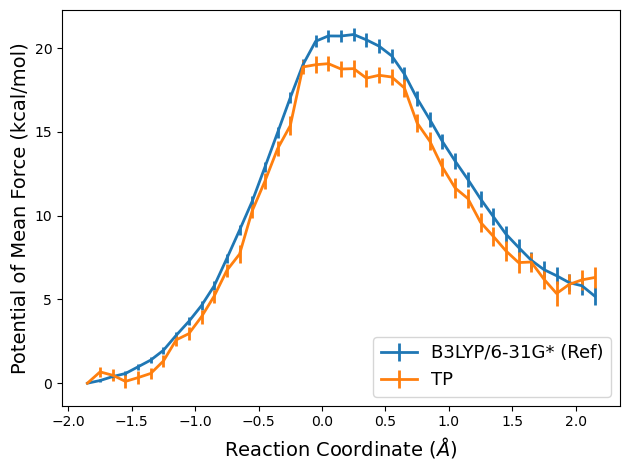

In [19]:
# Important cell, u_kn=high level of theory .... ARRAY SHOULD BE [WINDOWS,ENERGIES]

bin_centers, f_i_rw, df_i_rw, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins,u_kn=ene_wb97xd, uncertainties='from-specified', pmf_reference=f_i[:20].argmin())
# np.savetxt("tp_energy/freefile_mbar_b3lyp_d", np.column_stack((bin_centers, f_i_rw, df_i_rw)), fmt="%.2f %f %f")
np.savetxt("reweighting_entropy_wb97xd", np.column_stack((bin_centers, reweighting_entropy)), fmt="%.2f %f")

plt.xlabel("Reaction Coordinate ($\AA$)", fontsize=14)
plt.ylabel("Potential of Mean Force (kcal/mol)", fontsize=14)
plt.errorbar(bin_centers, f_i - f_i[0], yerr=df_i, linewidth=2.0, label="B3LYP/6-31G* (Ref)")
plt.errorbar(bin_centers, f_i_rw - f_i_rw[0], yerr=df_i_rw, linewidth=2.0, label="TP")
plt.tight_layout()
plt.legend(fontsize=13, loc=4)
# plt.savefig('pmg-TP-wB97XD.png', dpi=300)

In [14]:
# IF PMF IS NOT SMOOTH, THIS CODE USES GPR TO SMOOTHEN
likelihood_all = []
for i in range(300):
    alpha = (i + 1) * 0.01
    y_pred, sigma, likelihood = mbar.get_reweighted_tp(bin_centers, f_i_rw, reweighting_entropy, alpha)
    likelihood_all.append(likelihood)
print(np.array(likelihood_all).max(), np.array(likelihood_all).argmax())

/home/van/.Programs/miniforge3/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:629: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


-66.75283724199488 30


Barrier Height (kcal/mol): 22.52


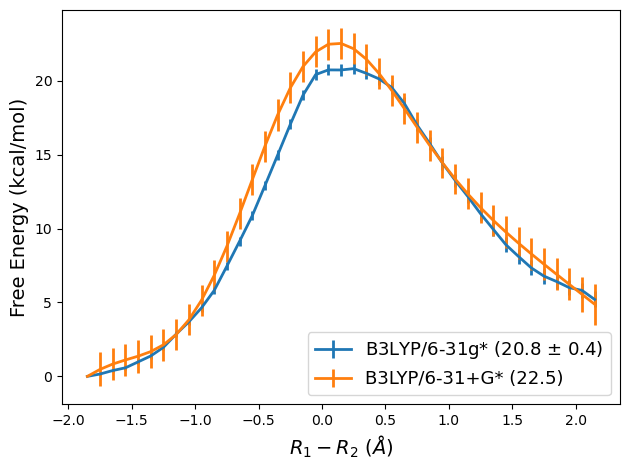

In [16]:
y_pred, sigma, likelihood = mbar.get_reweighted_tp(bin_centers, f_i_rw, reweighting_entropy, 0.57)
sigma2 = sigma + sigma[y_pred[:10].argmin()]
sigma2[y_pred[:10].argmin()] = 0.0
plt.xlabel("$R_{1} - R_{2}$ ($\AA$)", fontsize=14)
plt.ylabel("Free Energy (kcal/mol)", fontsize=14)

plt.errorbar(bin_centers, f_i - f_i[:10].min(), yerr=df_i, linewidth=2.0, label="B3LYP/6-31g* (%.1f $\pm$ %.1f)" % (f_i.max() - f_i[:10].min(), df_i[f_i.argmax()]))
plt.errorbar(bin_centers, y_pred - y_pred[:10].min(), yerr=sigma2, linewidth=2.0, label=r"B3LYP/6-31+G* (%.1f)" % (y_pred.max() - y_pred[:10].min()))


plt.legend(fontsize=13, loc=4)
print("Barrier Height (kcal/mol): %.2f" % (y_pred.max() - y_pred[:10].min()))
np.savetxt("tp_energy/freefile_mbar_b3lyp_d_gpr", np.column_stack((bin_centers, y_pred, sigma2)), fmt="%.2f %f %f")
plt.tight_layout()
# plt.savefig("pmf-TP-wB97XD-gpr.png", dpi=300)

In [ ]:

bin_centers, f_i_rw, df_i_rw, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins, u_kn=ene_wb97xd, uncertainties='from-specified', pmf_reference=f_i[:20].argmin())
np.savetxt("tp_energy/freefile_mbar_wb97xd", np.column_stack((bin_centers, f_i_rw, df_i_rw)), fmt="%.2f %f %f")

plt.xlabel("Reaction Coordinate ($\AA$)", fontsize=14)
plt.ylabel("Potential of Mean Force (kcal/mol)", fontsize=14)
plt.errorbar(bin_centers, f_i - f_i[0], yerr=df_i, linewidth=2.0, label="B3LYP/6-31g*")
plt.errorbar(bin_centers, f_i_rw - f_i_rw[0], yerr=df_i_rw, linewidth=2.0, label="BLYP/6-31G*")
plt.tight_layout()
plt.legend(fontsize=13, loc=4)

# IF PMF IS NOT SMOOTH, THIS CODE USES GPR TO SMOOTHEN
likelihood_all = []
for i in range(100):
    alpha = (i + 1) * 0.01
    y_pred, sigma, likelihood = mbar.get_reweighted_tp(bin_centers, f_i_rw, reweighting_entropy, alpha)
    likelihood_all.append(likelihood)
print(np.array(likelihood_all).max(), np.array(likelihood_all).argmax())

y_pred, sigma, likelihood = mbar.get_reweighted_tp(bin_centers, f_i_rw, reweighting_entropy, 0.57)
sigma2 = sigma + sigma[y_pred[:10].argmin()]
sigma2[y_pred[:10].argmin()] = 0.0
plt.xlabel("$R_{1} - R_{2}$ ($\AA$)", fontsize=14)
plt.ylabel("Free Energy (kcal/mol)", fontsize=14)

plt.errorbar(bin_centers, f_i - f_i[:10].min(), yerr=df_i, linewidth=2.0, label="B3LYP/6-31g* (%.1f $\pm$ %.1f)" % (f_i.max() - f_i[:10].min(), df_i[f_i.argmax()]))
plt.errorbar(bin_centers, y_pred - y_pred[:10].min(), yerr=sigma2, linewidth=2.0, label=r"B3LYP/6-31+G* (%.1f)" % (y_pred.max() - y_pred[:10].min()))
plt.legend(fontsize=13, loc=4)
print("Barrier Height (kcal/mol): %.2f" % (y_pred.max() - y_pred[:10].min()))
np.savetxt("tp_energy/freefile_mbar_wb97xd_gpr", np.column_stack((bin_centers, y_pred, sigma2)), fmt="%.2f %f %f")
plt.tight_layout()


In [ ]:
plt.xlabel("Reaction Coordinate (\AA)")
plt.ylabel("Reweighting Entropy")
plt.plot(bin_centers, reweighting_entropy, '-o')
print("Barrier Height (kcal/mol): %.2f" % (f_i_rw.max() - f_i_rw[:10].min()))
print("Mean Uncertainty (kcal/mol): %.2f" % df_i_rw.mean())
print("Reweighting Entropy:\n", reweighting_entropy)

In [ ]:
n_images = 40
n_dims = 2
images_cm = np.zeros((n_images, n_dims*2))
images2_cm = np.zeros((n_images, n_dims*2))
images3_cm = np.zeros((n_images, n_dims*2))
images4_cm = np.zeros((n_images, n_dims*2))

window = 40

for i in range(n_images):
    fnames = sorted(glob('../%02d/step6.00_equilibration_qt.cv' % i))
    d1 = np.concatenate([np.loadtxt(f, usecols=1)[2001::] for f in fnames[:]])
    d2 = np.concatenate([np.loadtxt(f, usecols=2)[2001::] for f in fnames[:]])
    images_cm[i, 0] = ((d2 + d1)/2).mean()
    images_cm[i, 1] = ((d2 - d1)/2).mean()
    images_cm[i, 2] = ((d2 + d1)/2).std()
    images_cm[i, 3] = ((d2 - d1)/2).std()
for i in range(n_images):
    fnames = sorted(glob('/work/panxl/qmmm_mts/chorismate_mutase/pbc2/b3lyp2/%02d/step6.??_equilibration.cv' % i))
    d1 = np.concatenate([np.loadtxt(f, usecols=1) for f in fnames[4:]])
    d2 = np.concatenate([np.loadtxt(f, usecols=2) for f in fnames[4:]])
    images2_cm[i, 0] = ((d2 + d1)/2).mean()
    images2_cm[i, 1] = ((d2 - d1)/2).mean()
    images2_cm[i, 2] = ((d2 + d1)/2).std()
    images2_cm[i, 3] = ((d2 - d1)/2).std()
for i in range(n_images):
    fnames = sorted(glob('../%02d/step6.00_equilibration.cv' % i))
    d1 = np.concatenate([np.loadtxt(f, usecols=1) for f in fnames[:]])[2001:]
    d2 = np.concatenate([np.loadtxt(f, usecols=2) for f in fnames[:]])[2001:]
    images3_cm[i, 0] = ((d2 + d1)/2).mean()
    images3_cm[i, 1] = ((d2 - d1)/2).mean()
    images3_cm[i, 2] = ((d2 + d1)/2).std()
    images3_cm[i, 3] = ((d2 - d1)/2).std()
# for i in range(n_images):
#     fnames = sorted(glob('../../b3lyp_mts12_langevin_mid/%02d/step6.00_equilibration.cv' % i))
#     d1 = np.concatenate([np.loadtxt(f, usecols=1) for f in fnames[:]])[:]
#     d2 = np.concatenate([np.loadtxt(f, usecols=2) for f in fnames[:]])[:]
#     images4_cm[i, 0] = ((d2 + d1)/2).mean()
#     images4_cm[i, 1] = ((d2 - d1)/2).mean()
#     images4_cm[i, 2] = ((d2 + d1)/2).std()
#     images4_cm[i, 3] = ((d2 - d1)/2).std()

In [ ]:
fig, ax = plt.subplots()

ax.set_aspect('equal', 'box')
ax.errorbar(images_cm[:, 0], images_cm[:, 1], xerr=images_cm[:, 2], yerr=images_cm[:, 3], fmt='-', linewidth=1, label="B3LYP")
ax.errorbar(images2_cm[:, 0], images2_cm[:, 1], xerr=images2_cm[:, 2], yerr=images2_cm[:, 3], fmt='-', linewidth=1, label="MTS")
ax.errorbar(images3_cm[:, 0], images3_cm[:, 1], xerr=images3_cm[:, 2], yerr=images3_cm[:, 3], fmt='-', linewidth=1, label="PM6")
# ax.errorbar(images4_cm[window:, 0], images4_cm[window:, 1], xerr=images4_cm[window:, 2], yerr=images4_cm[window:, 3], fmt='-', linewidth=1, label="PM6-1")
# ax.plot(images_cm[:, 0], images_cm[:, 1], '.-', linewidth=1, label="NEW")
# ax.plot(images2_cm[:, 0], images2_cm[:, 1], '.-', linewidth=1, label="OLD")
# ax.plot(images3_cm[:, 0], images3_cm[:, 1], '.-', linewidth=1, label="MTS 8fs/1fs End")
# ax.plot(images4_cm[:, 0], images4_cm[:, 1], '.-', linewidth=1, label="MTS 8fs/1fs Mid")

ax.set_xlabel("$d_\mathrm{C-O}$ (Å)", fontsize=12)
ax.set_ylabel("$d_\mathrm{C-C}$ (Å)", fontsize=12)
ax.set_xticks(np.linspace(1.5, 3.5, 5))
ax.set_yticks(np.linspace(1.5, 3.5, 5))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.legend(fontsize=12)
ax.set_aspect('equal', 'box')
ax.grid(b=None, which='both', axis='both')

# ax.plot(images2_cm[13, 0], images2_cm[13, 1], 'r*', linewidth=1, label="MTS")
# ax.plot(images2_cm[17, 0], images2_cm[17, 1], 'k*', linewidth=1, label="MTS")

fig.subplots_adjust(hspace=0.2)
fig.tight_layout()
# fig.savefig("pathway.pdf")

In [ ]:
a = !grep EPtot ../00/step6.00_equilibration.mdout | head -501 | tail -500
epot = np.loadtxt(a, usecols=8)
a = !grep EPtot ../00/step6.00_equilibration_qt.mdout | head -501 | tail -500
epot1 = np.loadtxt(a, usecols=8)

In [ ]:
plt.hist(epot, bins=40, density=False, alpha=0.5)
plt.hist(epot1, bins=40, density=False, alpha=0.5)
# plt.hist(epot2, bins=40, density=False, alpha=0.5)
# plt.hist(np.concatenate((epot, epot1)), bins=40, range=[-7000, -6600], density=False, alpha=0.5)
# plt.hist(epot3, bins=40, range=[-6800, -6400], density=False, alpha=0.5)

In [ ]:
a = !grep ESCF ../36/step6.00_equilibration.mdout | head -501 | tail -500
epot = np.loadtxt(a, usecols=1)
a = !grep ESCF ../36/step6.00_equilibration_qt.mdout | head -501 | tail -500
epot1 = np.loadtxt(a, usecols=1) / 0.9375
# a = !grep PM3ESCF ../00/step6.00_equilibration_320.mdout | head -501 | tail -500
# epot2 = np.loadtxt(a, usecols=1)
# a = !grep PM3ESCF ../00/step6.00_equilibration_330.mdout | head -501 | tail -500
# epot3 = np.loadtxt(a, usecols=1)

In [ ]:
plt.hist(epot, bins=40, density=False, alpha=0.5, label="300")
plt.hist(epot1, bins=40, density=False, alpha=0.5, label="320")
# plt.hist(epot2, bins=40, density=False, alpha=0.5, label="320")
# plt.hist(epot3, bins=40, density=False, alpha=0.5, label="330")
# plt.hist(np.concatenate((epot[:len(epot1)], epot1)), bins=40, density=False, alpha=0.5)
# plt.hist(epot3, bins=40, range=[-6800, -6400], density=False, alpha=0.5)
plt.legend()

In [ ]:
kcat=0.004
kb=1.3806452e-23 / 1000 / 4.184
h=6.6260701e-34 / 1000 / 4.184
T=298
R=8.314 / 1000 / 4.184

In [ ]:
np.log((kcat*h)/(kb*T))*R*T

In [ ]:
!jupyter nbconvert --to python reweightingTP.ipynb